Import Liblary yang akan digunakan


---



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample
from sklearn.feature_selection import SelectFromModel

Membaca file CSV dan Menampilkan Preview menggunakan pandas

---



In [ ]:
data = pd.read_csv('Employee.csv')
data.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


Menampilkan Jumlah data dan Kolam / Row dalam data CSV

---



In [ ]:
data.shape

(4653, 9)

Menampilkan Informasi Penting Terkait Data Tersebut

---



In [ ]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB


,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot
count,4653.000000,4653.000000,4653.000000,4653.000000,4653.000000
mean,2015.062970,2.698259,29.393295,2.905652,0.343864
std,1.863377,0.561435,4.826087,1.558240,0.475047
min,2012.000000,1.000000,22.000000,0.000000,0.000000
25%,2013.000000,3.000000,26.000000,2.000000,0.000000
50%,2015.000000,3.000000,28.000000,3.000000,0.000000
75%,2017.000000,3.000000,32.000000,4.000000,1.000000
max,2018.000000,3.000000,41.000000,7.000000,1.000000


Menghitung jumlah nilai yang hilang (missing values) pada setiap kolom dalam sebuah DataFrame.

In [ ]:
data.isnull().sum()

,0
Education,0
JoiningYear,0
City,0
PaymentTier,0
Age,0
Gender,0
EverBenched,0
ExperienceInCurrentDomain,0
LeaveOrNot,0


Menganalisis distribusi nilai pada variabel target LeaveOrNot

---



In [ ]:
print("\nDistribusi Target Variable (LeaveOrNot):")
leave_distribution = data['LeaveOrNot'].value_counts()
print(leave_distribution)
print(f"Persentase karyawan yang meninggalkan perusahaan: {leave_distribution[1]/len(data)*100:.2f}%")
print(f"Persentase karyawan yang tetap di perusahaan: {leave_distribution[0]/len(data)*100:.2f}%")


Distribusi Target Variable (LeaveOrNot):
LeaveOrNot
0    3053
1    1600
Name: count, dtype: int64
Persentase karyawan yang meninggalkan perusahaan: 34.39%
Persentase karyawan yang tetap di perusahaan: 65.61%


Visualisasi perbandingan jumlah karyawan yang tetap di perusahaan (0) dan yang meninggalkan perusahaan (1).

---



<ipython-input-7-6a78e7e70841>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='LeaveOrNot', data=data, palette='viridis')


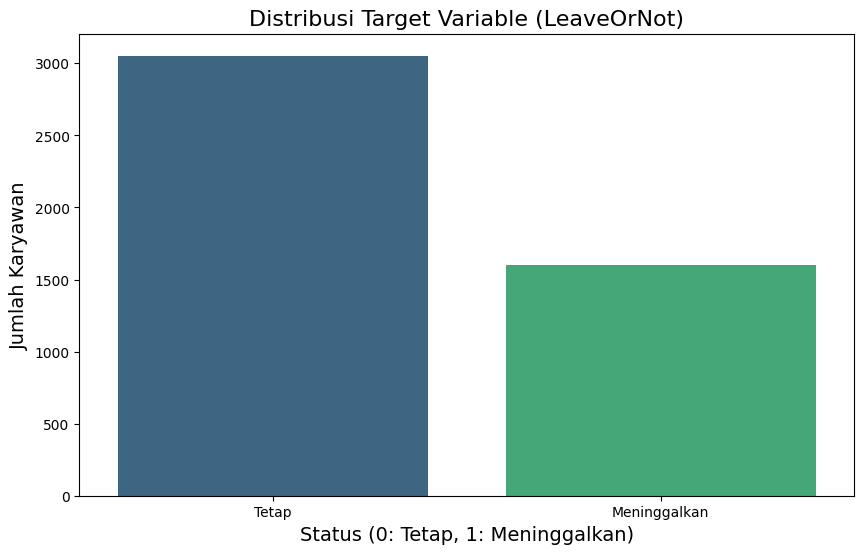

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='LeaveOrNot', data=data, palette='viridis')
plt.title('Distribusi Target Variable (LeaveOrNot)', fontsize=16)
plt.xlabel('Status (0: Tetap, 1: Meninggalkan)', fontsize=14)
plt.ylabel('Jumlah Karyawan', fontsize=14)
plt.xticks([0, 1], ['Tetap', 'Meninggalkan'])
plt.savefig('distribusi_target_variable.png')
plt.show()

Visualisasi distribusi variabel numerik berdasarkan status karyawan yang meninggalkan perusahaan (LeaveOrNot)

---



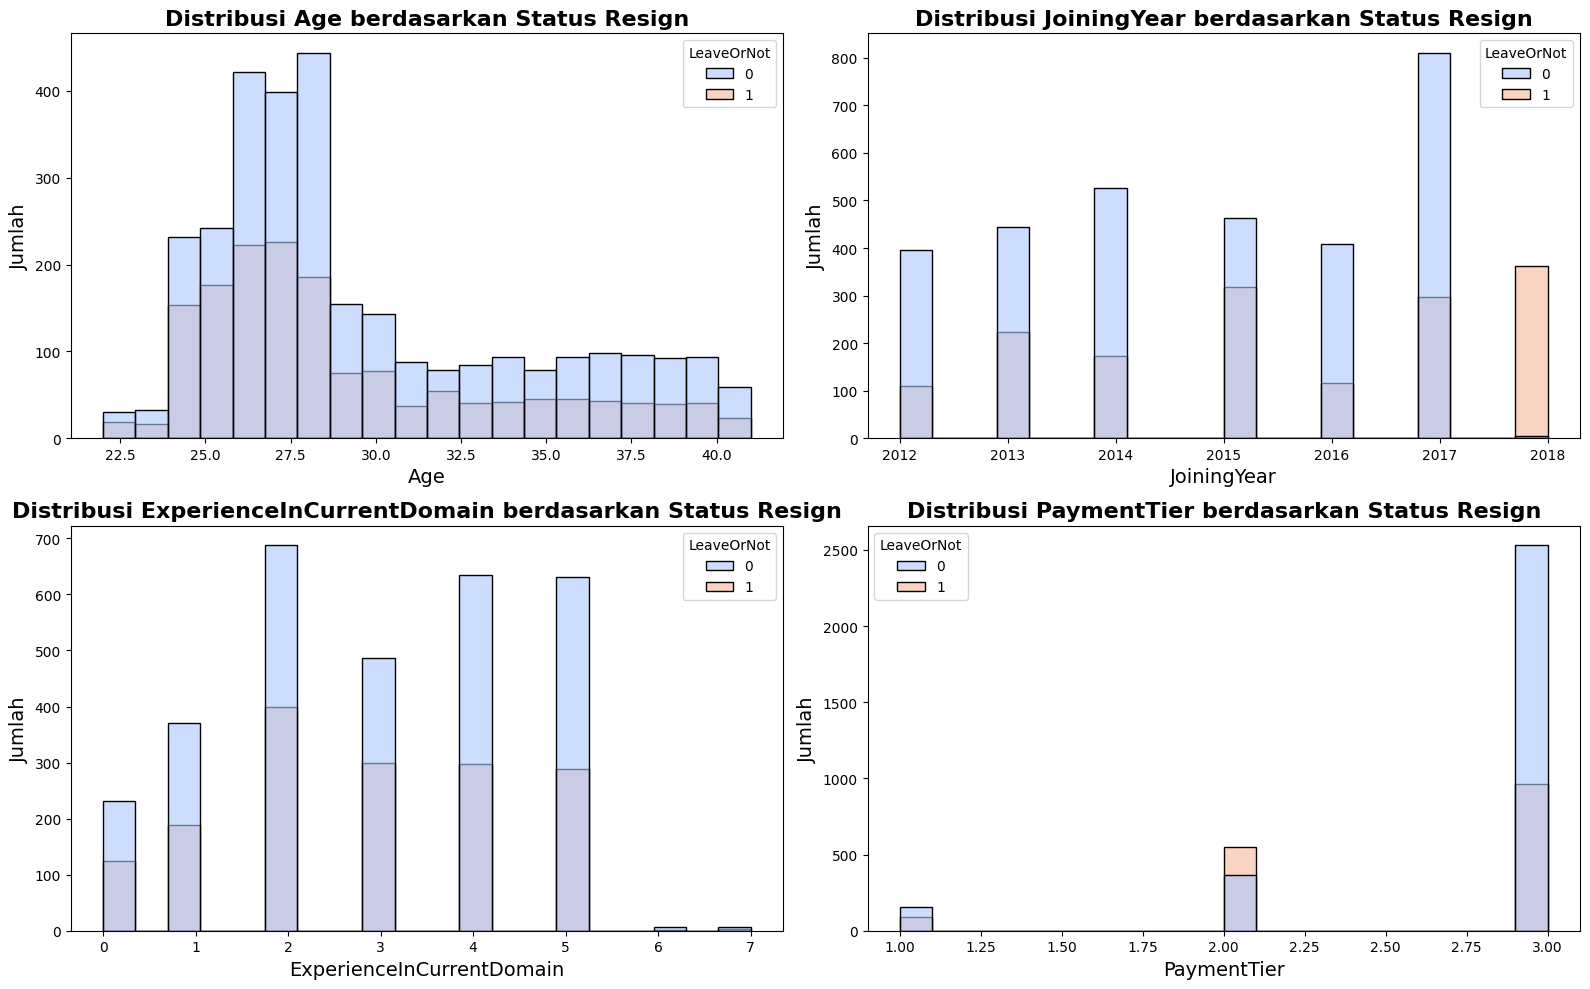

In [ ]:
plt.figure(figsize=(16, 10))
numerical_features = ['Age', 'JoiningYear', 'ExperienceInCurrentDomain', 'PaymentTier']
for i, column in enumerate(numerical_features):
    plt.subplot(2, 2, i+1)
    sns.histplot(data=data, x=column, hue='LeaveOrNot', kde=False, palette='coolwarm',
                bins=20, stat='count', alpha=0.6)
    plt.title(f'Distribusi {column} berdasarkan Status Resign', fontsize=16, weight='bold')
    plt.xlabel(f'{column}', fontsize=14)
    plt.ylabel('Jumlah', fontsize=14)
plt.tight_layout()
plt.savefig('distribusi_variabel_numerik.png', dpi=300)
plt.show()

Visualisasi distribusi variabel kategorikal berdasarkan status karyawan yang
meninggalkan perusahaan (LeaveOrNot).

---



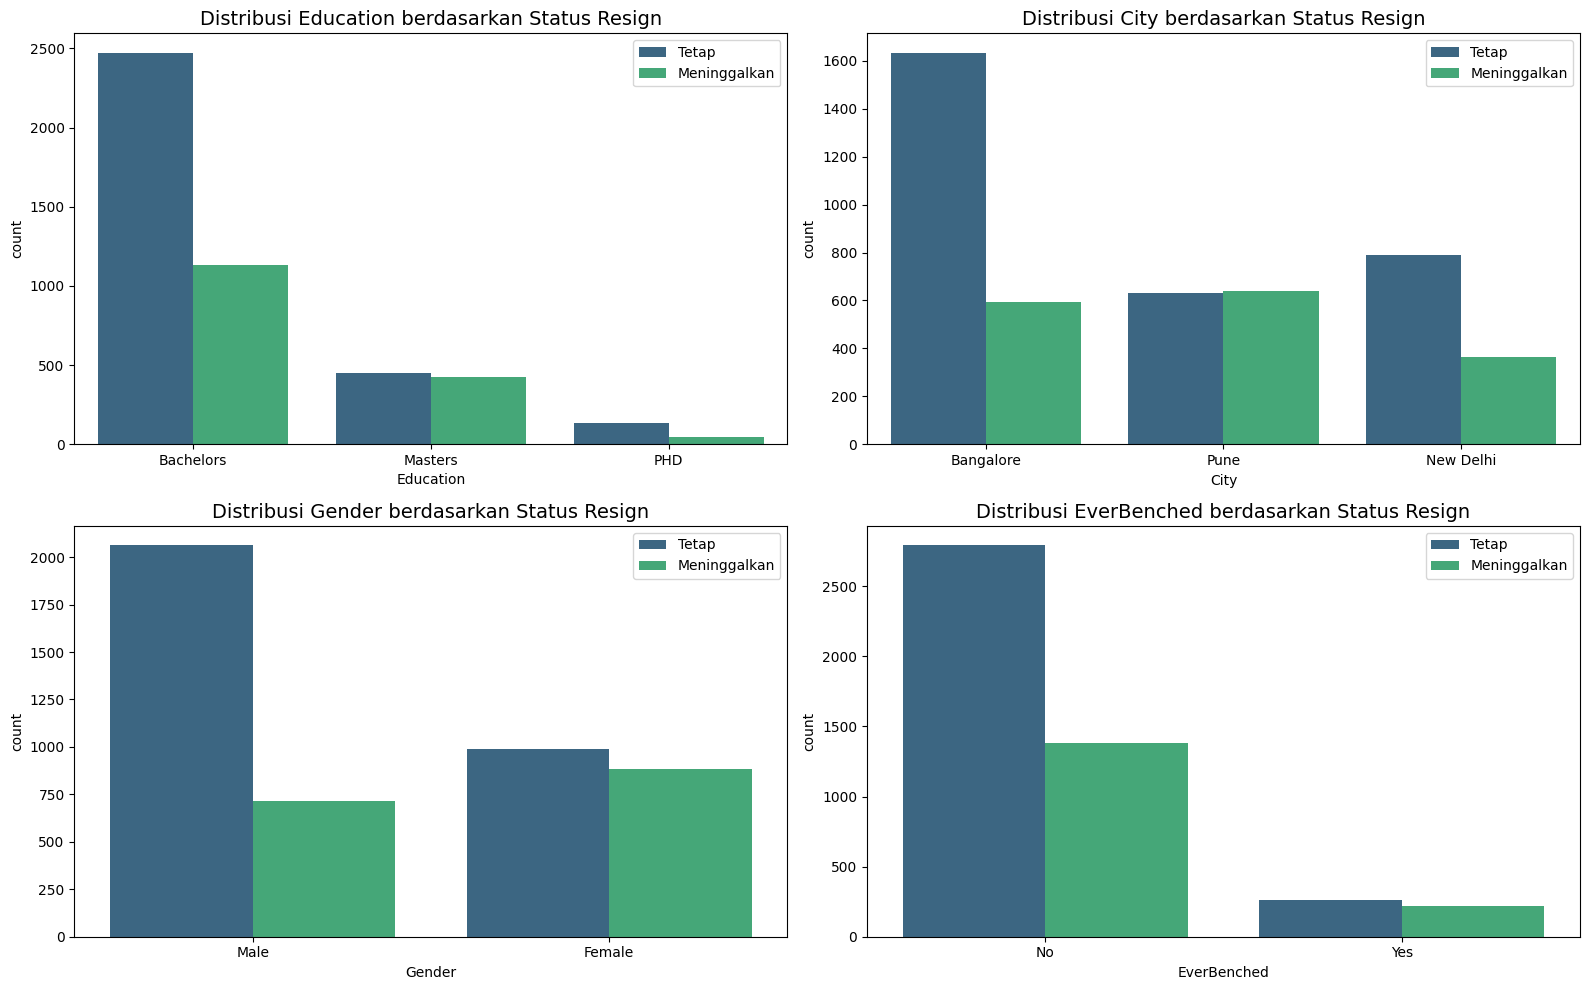

In [ ]:
plt.figure(figsize=(16, 10))
categorical_features = ['Education', 'City', 'Gender', 'EverBenched']
for i, column in enumerate(categorical_features):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=column, hue='LeaveOrNot', data=data, palette='viridis')
    plt.title(f'Distribusi {column} berdasarkan Status Resign', fontsize=14)
    plt.xticks(rotation=0)
    plt.legend(['Tetap', 'Meninggalkan'])
plt.tight_layout()
plt.savefig('distribusi_variabel_kategorikal.png')
plt.show()

Visualisasi heatmap matriks korelasi Untuk Fitur Numeric

---

Nilai korelasi berada antara -1 dan 1, dengan:
*   1 menunjukkan korelasi positif sempurna.
*   -1 menunjukkan korelasi negatif sempurna.
*   0 menunjukkan tidak ada korelasi linier.

warna biru menunjukkan korelasi negatif, sedangkan warna merah menunjukkan korelasi positif. Warna yang lebih gelap atau terang menunjukkan tingkat korelasi yang lebih kuat yang berguna untuk menganalisis hubungan antar fitur numerik untuk analisis lebih lanjut.





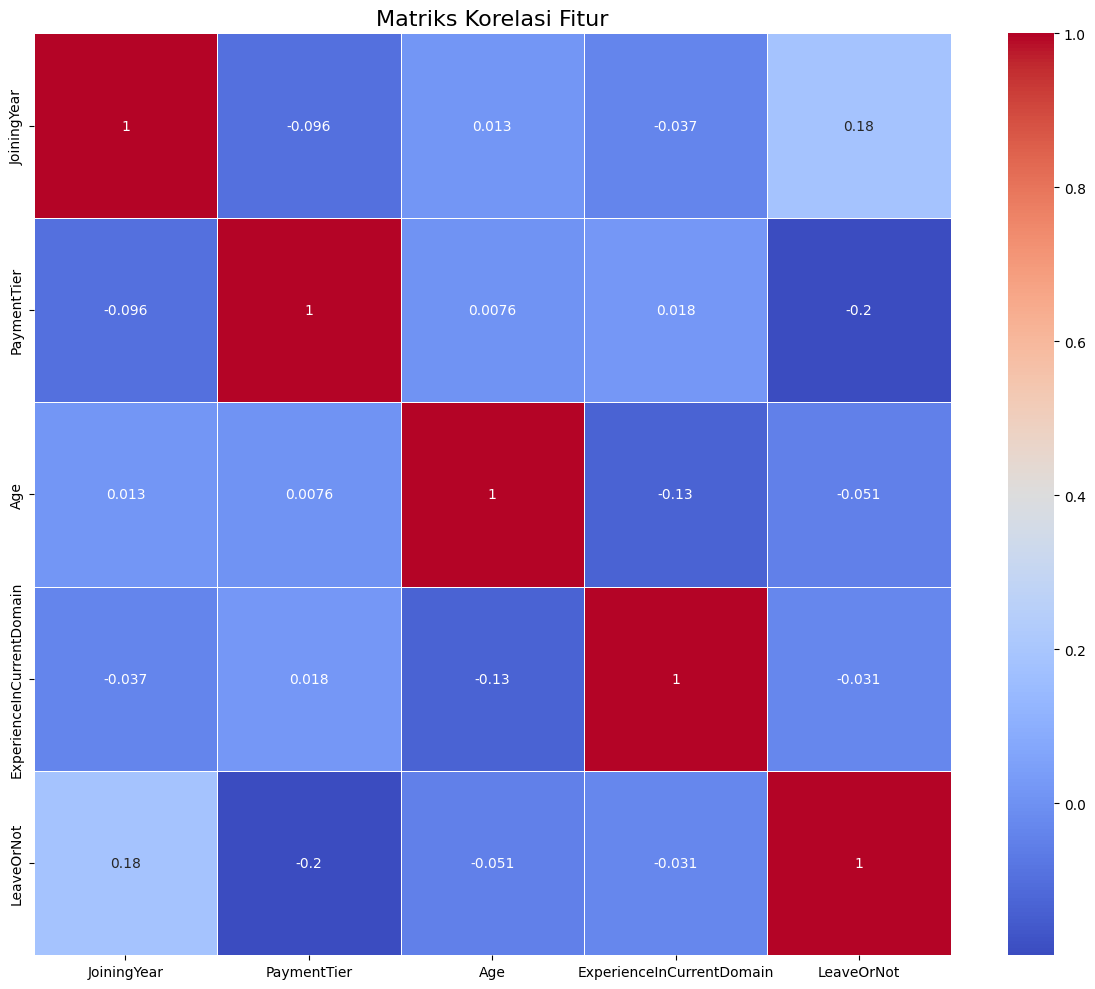

In [ ]:
numeric_data = data.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 10))
correlation_matrix = numeric_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriks Korelasi Fitur', fontsize=16)
plt.tight_layout()
plt.savefig('matriks_korelasi.png')
plt.show()


Mempersiapkan data variable target dan membagi dataset menjadi set (training 0.8) dan (test 0.2)
dengan fokus pada variabel target LeaveOrNot

---



In [ ]:
y = data['LeaveOrNot']
X = data.drop('LeaveOrNot', axis=1)

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Kolom Kategorikal:", categorical_cols)
print("Kolom Numerikal:", numerical_cols)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Kolom Kategorikal: ['Education', 'City', 'Gender', 'EverBenched']
Kolom Numerikal: ['JoiningYear', 'PaymentTier', 'Age', 'ExperienceInCurrentDomain']


Pra-pemrosesan data dengan menormalisasi data untuk fitur numerik dan kategorikal

---

Fitur numerik dinormalisasi dengan StandardScaler untuk mengubah nilainya sehingga memiliki rata-rata 0 dan standar deviasi 1 yang memudahkan model dalam memahami data.

Fitur kategorikal diubah menjadi one-hot encoding yang berarti setiap kategori akan dipisahkan menjadi kolom baru (dummy). Namun, kategori pertama dihilangkan agar tidak ada pengulangan informasi (multikolinearitas).

In [ ]:
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numerical_cols])
X_test_num = scaler.transform(X_test[numerical_cols])

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

Menggabungkan fitur numerik dan kategorikal menjadi satu dataset yang utuh yang akan digunakan untuk training dan test pada model yang akan digunakan.

---



In [ ]:
X_train_final = np.hstack((X_train_num, X_train_cat))
X_test_final = np.hstack((X_test_num, X_test_cat))

print(f"\nBentuk set pelatihan: {X_train.shape}")
print(f"Bentuk set pengujian: {X_test.shape}")


Bentuk set pelatihan: (3722, 8)
Bentuk set pengujian: (931, 8)


Melakukan seleksi fitur menggunakan model DecisionTreeClassifier untuk memilih fitur yang paling penting berdasarkan kinerja model

---

Seleksi fitur ini berguna dalam mengurangi dimensi data, meningkatkan efisiensi model, dan mengurangi kemungkinan overfitting dengan hanya menggunakan fitur-fitur yang relevan.

In [ ]:
selector = SelectFromModel(DecisionTreeClassifier(random_state=42, max_depth=5), threshold="median")
X_train_selected = selector.fit_transform(X_train_final, y_train)
X_test_selected = selector.transform(X_test_final)

print(f"Jumlah fitur sebelum seleksi: {X_train_final.shape[1]}")
print(f"Jumlah fitur setelah seleksi: {X_train_selected.shape[1]}")

Jumlah fitur sebelum seleksi: 10
Jumlah fitur setelah seleksi: 5


Memeriksa distribusi kelas pada variabel target (LeaveOrNot) dalam data training dan data test.

---



In [ ]:
print("\nDistribusi kelas pada data training:")
print(y_train.value_counts())

print("\nDistribusi kelas pada data testing:")
print(y_test.value_counts())


Distribusi kelas pada data training:
LeaveOrNot
0    2442
1    1280
Name: count, dtype: int64

Distribusi kelas pada data testing:
LeaveOrNot
0    611
1    320
Name: count, dtype: int64


Menyeimbangkan distribusi kelas dalam dataset pelatihan menggunakan teknik SMOTE (Synthetic Minority Over-sampling Technique).

---

SMOTE dapat membantu memperbaiki masalah ketidakseimbangan kelas dengan menghasilkan data sintetik untuk kelas minoritas yang dapat berpengaruh untuk meningkatkan kinerja model.

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_selected, y_train)

print("\nDistribusi sebelum SMOTE:")
print(pd.Series(y_train).value_counts())

print("\nDistribusi setelah SMOTE:")
print(pd.Series(y_train_smote).value_counts())


Distribusi sebelum SMOTE:
LeaveOrNot
0    2442
1    1280
Name: count, dtype: int64

Distribusi setelah SMOTE:
LeaveOrNot
0    2442
1    2442
Name: count, dtype: int64


Visualisasi distribusi kelas dalam dataset pelatihan sebelum dan setelah menerapkan teknik SMOTE (Synthetic Minority Over-sampling Technique) untuk menyeimbangkan jumlah kelas.

---

Dengan ini jumlah data kelas minoritas (kelas 1) akan ditambah dengan data sintetis untuk memastikan distribusi yang lebih seimbang, yang dapat meningkatkan kinerja model prediksi.

<ipython-input-17-d6364306ec81>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')
<ipython-input-17-d6364306ec81>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote, palette='viridis')


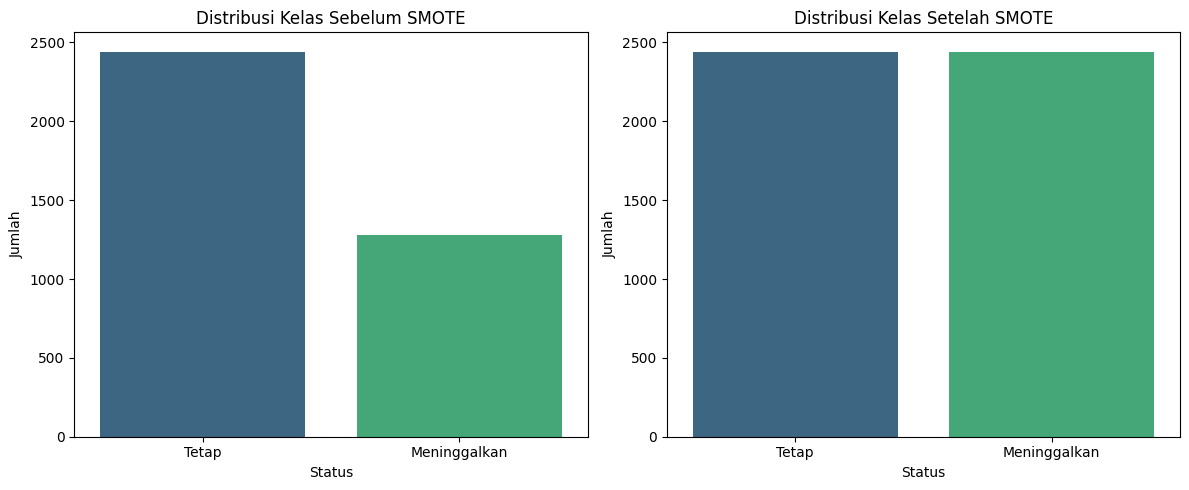

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train, palette='viridis')
plt.title("Distribusi Kelas Sebelum SMOTE")
plt.xlabel("Status")
plt.ylabel("Jumlah")
plt.xticks([0, 1], ['Tetap', 'Meninggalkan'])

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_smote, palette='viridis')
plt.title("Distribusi Kelas Setelah SMOTE")
plt.xlabel("Status")
plt.ylabel("Jumlah")
plt.xticks([0, 1], ['Tetap', 'Meninggalkan'])

plt.tight_layout()
plt.savefig("distribusi_setelah_smote.png")
plt.show()

Visualisasi Confusion Matrix untuk memperlihatkan perbandingan antara nilai prediksi model dan nilai sebenarnya (true labels).

---



In [ ]:
def plot_matriks_konfusi(y_true, y_pred, nama_model):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
    plt.xlabel('Label Prediksi')
    plt.ylabel('Label Sebenarnya')
    plt.title(f'Matriks Konfusi - {nama_model}')
    plt.tight_layout()
    plt.savefig(f'matriks_konfusi_{nama_model.lower().replace(" ", "_")}.png')
    plt.show()

Optimasi parameter pada model Decision Tree menggunakan GridSearchCV untuk mencari kombinasi parameter terbaik

---

GridSearchCV biasanya memberikan hasil yang lebih baik dalam pemilihan parameter yang akan menghasilkan model yang lebih efisien dan stabil, dengan tujuan untuk menghindari masalah pada model seperti overfitting.

In [ ]:
param_grid_dt = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [5, 10, 20],
    'ccp_alpha': [0.001, 0.01, 0.05]
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='f1')
grid_dt.fit(X_train_smote, y_train_smote)

print(f"Parameter terbaik Decision Tree: {grid_dt.best_params_}")
print(f"F1-Score CV terbaik: {grid_dt.best_score_:.4f}")

dt_model = grid_dt.best_estimator_
dt_model.fit(X_train_smote, y_train_smote)

Parameter terbaik Decision Tree: {'ccp_alpha': 0.001, 'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 20}
F1-Score CV terbaik: 0.7872


DecisionTreeClassifier(ccp_alpha=0.001, max_depth=7, min_samples_leaf=5,
                       min_samples_split=20, random_state=42)

Kinerja model Decision Tree yang telah dilatih dengan menggunakan data training yang telah menggunakan SMOTE

---

metrik evaluasi untuk model Decision Tree pada data pelatihan:
*   Akurasi: 0.8047 (model benar dalam memprediksi sekitar 80% dari data).
*   Presisi: 0.8553 (model akurat dalam memprediksi kelas positif).
*   Recall: 0.7334 (model berhasil menangkap 73.34% dari kelas positif yang sebenarnya).
*   F1-Score: 0.7897 (nilai rata-rata dari presisi dan recall, memberikan gambaran tentang keseimbangan keduanya).

Dan digunakan untuk menilai kinerja model dan membantu dalam menentukan apakah model sudah cukup baik dalam memprediksi kelas-kelas dalam dataset pelatihan.

In [ ]:
dt_train_pred = dt_model.predict(X_train_smote)
print("\n--- Metrik Evaluasi Decision Tree pada Data Training ---")
print(f"Akurasi: {accuracy_score(y_train_smote, dt_train_pred):.4f}")
print(f"Presisi: {precision_score(y_train_smote, dt_train_pred):.4f}")
print(f"Recall: {recall_score(y_train_smote, dt_train_pred):.4f}")
print(f"F1-Score: {f1_score(y_train_smote, dt_train_pred):.4f}")


--- Metrik Evaluasi Decision Tree pada Data Training ---
Akurasi: 0.8047
Presisi: 0.8553
Recall: 0.7334
F1-Score: 0.7897


Menilai kinerja model Decision Tree pada data test dengan menggunakan berbagai metrik evaluasi.

---

hasil evaluasi model Decision Tree pada data pengujian:
*   Akurasi model adalah 0.8228, artinya sekitar 82.28% prediksi model benar.
*   Presisi untuk kelas 0 adalah 0.87, dan untuk kelas 1 adalah 0.74.
*   Recall untuk kelas 0 adalah 0.86, dan untuk kelas 1 adalah 0.74.
*   F1-Score untuk kelas 0 adalah 0.86, dan untuk kelas 1 adalah 0.74.
*   Laporan Klasifikasi mencakup metrik evaluasi untuk setiap kelas, serta rata-rata (macro avg, weighted avg) untuk keseluruhan model.

Evaluasi ini digunakan untuk memahami sejauh mana model Decision Tree dapat memprediksi kelas dengan benar pada data pengujian, termasuk keseimbangan antara presisi dan recall.

In [ ]:
dt_test_pred = dt_model.predict(X_test_selected)
print("\n--- Metrik Evaluasi Decision Tree pada Data Testing ---")
dt_accuracy = accuracy_score(y_test, dt_test_pred)
dt_precision = precision_score(y_test, dt_test_pred)
dt_recall = recall_score(y_test, dt_test_pred)
dt_f1 = f1_score(y_test, dt_test_pred)

print(f"Akurasi: {dt_accuracy:.4f}")
print(f"Presisi: {dt_precision:.4f}")
print(f"Recall: {dt_recall:.4f}")
print(f"F1-Score: {dt_f1:.4f}")

print("\nLaporan Klasifikasi Decision Tree:")
print(classification_report(y_test, dt_test_pred))


--- Metrik Evaluasi Decision Tree pada Data Testing ---
Akurasi: 0.8228
Presisi: 0.7414
Recall: 0.7438
F1-Score: 0.7426

Laporan Klasifikasi Decision Tree:
              precision    recall  f1-score   support

           0       0.87      0.86      0.86       611
           1       0.74      0.74      0.74       320

    accuracy                           0.82       931
   macro avg       0.80      0.80      0.80       931
weighted avg       0.82      0.82      0.82       931



Visualisasi confusion matrix untuk menilai kinerja model Decision Tree pada data test.

---

Confusion matrix (empat kuadran):

- Kuadran 0,0 (528): Jumlah prediksi benar untuk kelas 0 (karyawan yang tetap).
- Kuadran 0,1 (83): Jumlah prediksi salah untuk kelas 0 (karyawan yang tetap) yang diprediksi sebagai kelas 1 (karyawan yang meninggalkan).
- Kuadran 1,0 (82): Jumlah prediksi salah untuk kelas 1 (karyawan yang meninggalkan) yang diprediksi sebagai kelas 0 (karyawan yang tetap).
- Kuadran 1,1 (238): Jumlah prediksi benar untuk kelas 1 (karyawan yang meninggalkan).

Berguna untuk memberikan gambaran tentang jumlah prediksi yang benar dan salah oleh model. Semakin besar angka di diagonal utama (kuadran 0,0 dan 1,1), semakin baik kinerja model dalam memprediksi kelas yang benar.

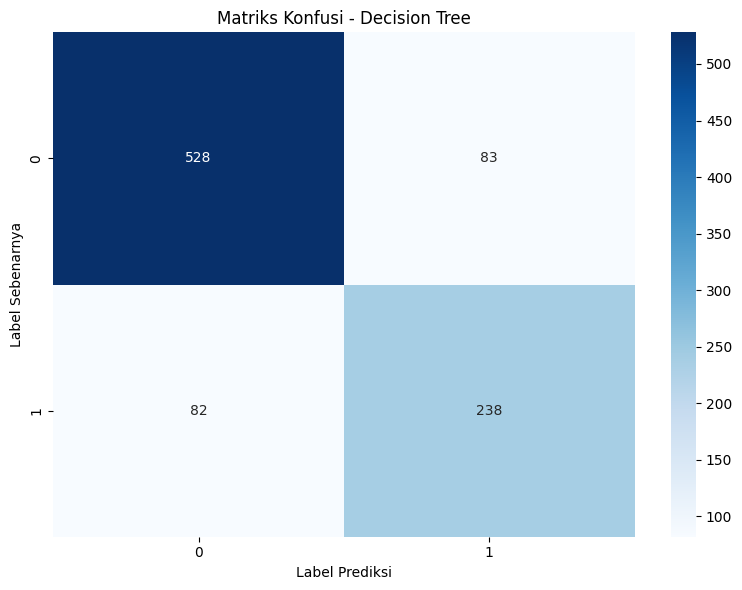

In [ ]:
plot_matriks_konfusi(y_test, dt_test_pred, "Decision Tree")

Optimasi parameter model K-Nearest Neighbors (KNN) menggunakan GridSearchCV untuk mencari kombinasi parameter terbaik yang dapat meningkatkan kinerja model.

---

Parameter yang dipilih digunakan untuk mencapai hasil terbaik yang akan menunjukkan keseimbangan antara presisi dan recall dalam prediksi model.

In [ ]:
param_grid_knn = {
    'n_neighbors': [7, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree']
}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='f1')
grid_knn.fit(X_train_smote, y_train_smote)

print(f"Parameter terbaik KNN: {grid_knn.best_params_}")
print(f"F1-Score CV terbaik: {grid_knn.best_score_:.4f}")

knn_model = grid_knn.best_estimator_
knn_model.fit(X_train_smote, y_train_smote)

Parameter terbaik KNN: {'algorithm': 'ball_tree', 'n_neighbors': 7, 'weights': 'uniform'}
F1-Score CV terbaik: 0.7677


KNeighborsClassifier(algorithm='ball_tree', n_neighbors=7)

Menilai kinerja model K-Nearest Neighbors (KNN) pada data training yang telah disiapkan menggunakan SMOTE

---

metrik evaluasi untuk model KNN pada data training:
- Akurasi: 0.8049 (model benar dalam memprediksi sekitar 80.49% dari data training).
- Presisi: 0.8929 (model akurat dalam memprediksi kelas positif).
- Recall: 0.6929 (model berhasil menangkap 69.29% dari kelas positif yang sebenarnya).
- F1-Score: 0.7083 (harmonisasi antara presisi dan recall, memberikan gambaran tentang keseimbangan keduanya).

Dan digunakan untuk mengevaluasi sejauh mana model dapat memprediksi data training dengan benar

In [ ]:
knn_train_pred = knn_model.predict(X_train_smote)
print("\n--- Metrik Evaluasi KNN pada Data Training ---")
print(f"Akurasi: {accuracy_score(y_train_smote, knn_train_pred):.4f}")
print(f"Presisi: {precision_score(y_train_smote, knn_train_pred):.4f}")
print(f"Recall: {recall_score(y_train_smote, knn_train_pred):.4f}")
print(f"F1-Score: {f1_score(y_train_smote, knn_train_pred):.4f}")


--- Metrik Evaluasi KNN pada Data Training ---
Akurasi: 0.8049
Presisi: 0.8929
Recall: 0.6929
F1-Score: 0.7803


Menilai kinerja model K-Nearest Neighbors (KNN) pada data test dengan menggunakan berbagai metrik evaluasi, serta menghasilkan laporan klasifikasi

---

metrik evaluasi untuk model KNN pada data test:
- Akurasi: 0.8346 (model benar dalam memprediksi sekitar 83.46% dari data test).
- Presisi: 0.8192 (model akurat dalam memprediksi kelas positif).
- Recall: 0.6656 (model berhasil menangkap 66.56% dari kelas positif yang sebenarnya).
- F1-Score: 0.7345 (harmonisasi antara presisi dan recall).

Detail Lainnya:
- Precision dan Recall untuk masing-masing kelas (kelas 0 dan kelas 1).
- F1-Score untuk masing-masing kelas dan rata-rata untuk seluruh model (macro avg, weighted avg).

Digunakan untuk memberikan gambaran menyeluruh tentang kemampuan model dalam menangani data test

In [ ]:
knn_test_pred = knn_model.predict(X_test_selected)
print("\n--- Metrik Evaluasi KNN pada Data Testing ---")
knn_accuracy = accuracy_score(y_test, knn_test_pred)
knn_precision = precision_score(y_test, knn_test_pred)
knn_recall = recall_score(y_test, knn_test_pred)
knn_f1 = f1_score(y_test, knn_test_pred)

print(f"Akurasi: {knn_accuracy:.4f}")
print(f"Presisi: {knn_precision:.4f}")
print(f"Recall: {knn_recall:.4f}")
print(f"F1-Score: {knn_f1:.4f}")

print("\nLaporan Klasifikasi KNN:")
print(classification_report(y_test, knn_test_pred))


--- Metrik Evaluasi KNN pada Data Testing ---
Akurasi: 0.8346
Presisi: 0.8192
Recall: 0.6656
F1-Score: 0.7345

Laporan Klasifikasi KNN:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88       611
           1       0.82      0.67      0.73       320

    accuracy                           0.83       931
   macro avg       0.83      0.79      0.81       931
weighted avg       0.83      0.83      0.83       931



Visualisasi confusion matrix untuk model K-Nearest Neighbors (KNN) pada data test. yang berguna untuk menunjukkan sejauh mana model dapat memprediksi kelas dengan benar.

---

confusion matrix (4 Kuadran):
- Kuadran 0,0 (564): Jumlah prediksi benar untuk kelas 0 (karyawan yang tetap).
- Kuadran 0,1 (47): Jumlah prediksi salah untuk kelas 0 yang diprediksi sebagai kelas 1 (karyawan yang meninggalkan).
- Kuadran 1,0 (107): Jumlah prediksi salah untuk kelas 1 yang diprediksi sebagai kelas 0.
- Kuadran 1,1 (213): Jumlah prediksi benar untuk kelas 1 (karyawan yang meninggalkan).

Digunakan untuk memberikan gambaran tentang seberapa baik model KNN memprediksi kelas pada data pengujian, dengan semakin besar angka di diagonal utama (kuadran 0,0 dan 1,1) menunjukkan semakin baik kinerja model dalam memprediksi kelas yang benar.

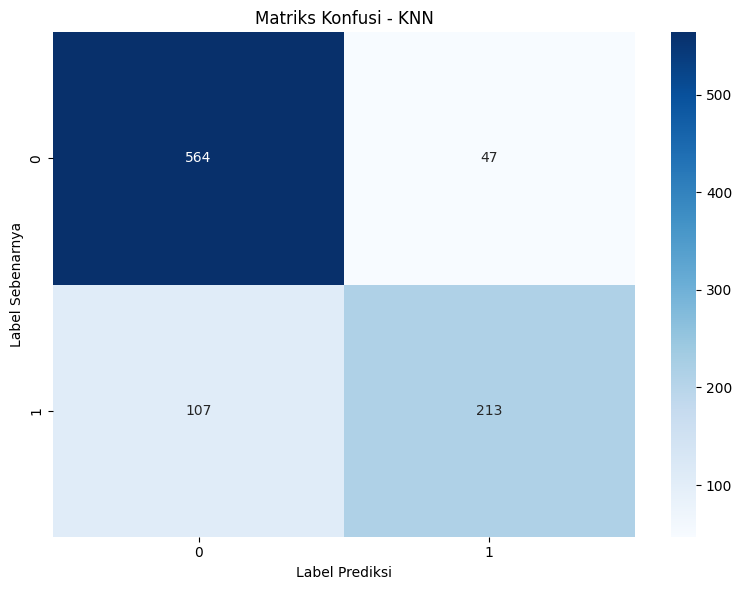

In [ ]:
plot_matriks_konfusi(y_test, knn_test_pred, "KNN")

Menggabungkan metrik evaluasi dari dua model (Decision Tree dan KNN) ke dalam satu DataFrame untuk bisa menganalisa perbandingan yang lebih mudah.

---



In [ ]:
dt_metrics = [dt_accuracy, dt_precision, dt_recall, dt_f1]
knn_metrics = [knn_accuracy, knn_precision, knn_recall, knn_f1]

performance_df = pd.DataFrame({
    'Decision Tree': dt_metrics,
    'KNN': knn_metrics,
}, index=['Akurasi', 'Presisi', 'Recall', 'F1-Score'])

performance_df.head()

,Decision Tree,KNN
Akurasi,0.822771,0.834586
Presisi,0.741433,0.819231
Recall,0.743750,0.665625
F1-Score,0.742590,0.734483


Visualisasikan perbandingan metrik evaluasi antara dua model (Decision Tree dan KNN) Untuk memberikan gambaran terkait kedua model tersebut

---



<Figure size 1200x800 with 0 Axes>

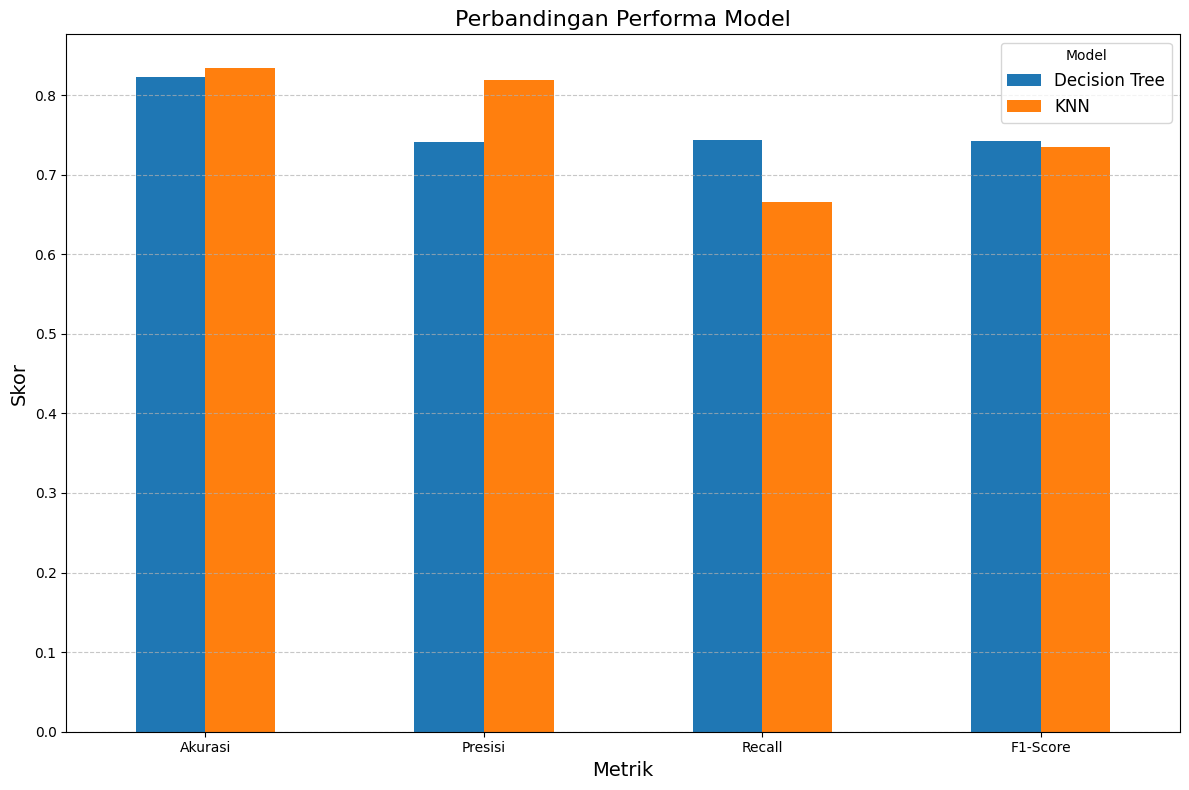

In [ ]:
plt.figure(figsize=(12, 8))
performance_df.plot(kind='bar', figsize=(12, 8), rot=0)
plt.title('Perbandingan Performa Model', fontsize=16)
plt.ylabel('Skor', fontsize=14)
plt.xlabel('Metrik', fontsize=14)
plt.legend(title='Model', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('perbandingan_performa_model.png')
plt.show()